In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.constants import k as k_B

In [27]:
m = 1
v = 10
mean_energy = m * v**2 / 2.0
temperature = mean_energy * 2.0 / (3.0 * k_B)
print(temperature)

2.41432350534664e+24


In [28]:
ppe = 2 * 5000
unique_pairs = ppe * (ppe - 1) / 2.0
print(unique_pairs)
sigma_cr_t_max_prev = 10
elem_volume = 1
number_density = 1
weight = number_density * elem_volume / ppe
_dt = 10
num_trials = unique_pairs * sigma_cr_t_max_prev * weight * _dt / elem_volume
print(num_trials)
print(num_trials / ppe)

49995000.0
499950.0
49.995


In [29]:
def f_M_v(v, T, m):
  return np.sqrt((m / (2 * np.pi * k_B * T))) * np.exp(- m * v**2 / (2 * k_B * T))


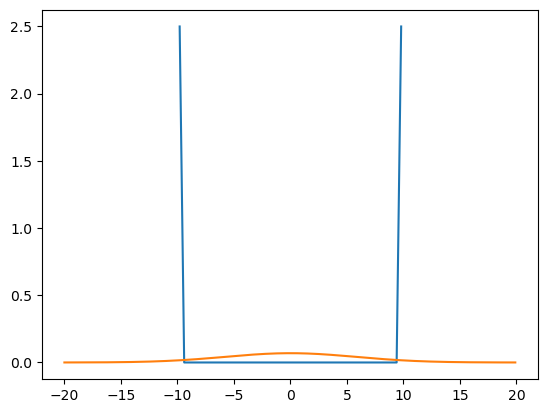

/var/folders/xd/j33m1sr94b77cjm186sf36q1np4cfh/T/ipykernel_61390/3891806570.py:12: RuntimeWarning: divide by zero encountered in divide
  pdf = vals / total
/var/folders/xd/j33m1sr94b77cjm186sf36q1np4cfh/T/ipykernel_61390/3891806570.py:12: RuntimeWarning: invalid value encountered in divide
  pdf = vals / total


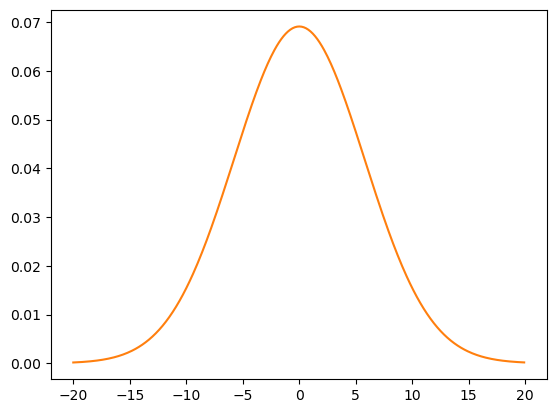

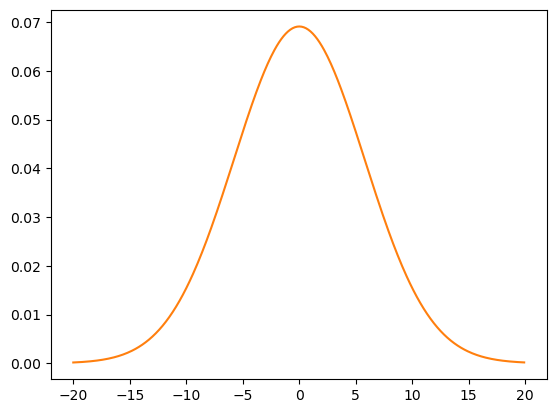

In [30]:
data = pd.read_csv(f"testing_out_distribution_0001.csv")

components = ['x', 'y', 'z']
v_max = 20
v_range = np.arange(-v_max, v_max, 1e-1)
for c in components:
    lower = data[f"v_{c}_lower"].to_numpy()
    upper = data[f"v_{c}_upper"].to_numpy()
    vals = data[f"v_{c}"].to_numpy()
    centers = (upper + lower) / 2
    total = np.trapezoid(vals, centers)
    pdf = vals / total

    plt.figure()
    plt.plot(centers, pdf)
    plt.plot(v_range, f_M_v(v_range, temperature, m))
    plt.show()

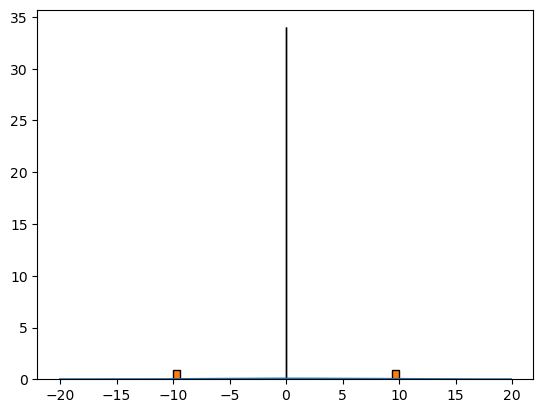

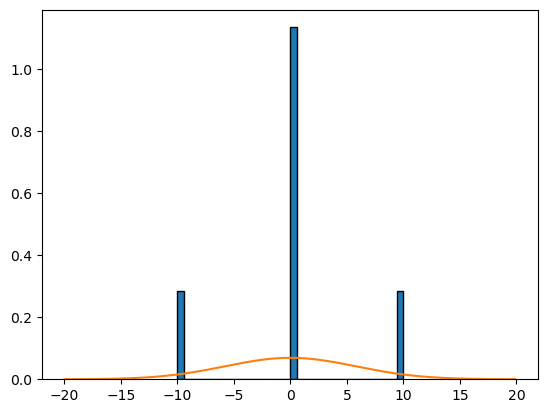

In [31]:
particle_data = pd.read_csv("testing_out_particles_0001.csv")

v_x = particle_data["v_x"].to_numpy()
v_y = particle_data["v_y"].to_numpy()
v_z = particle_data["v_z"].to_numpy()

components = [v_x, v_y, v_z]

plt.figure()
plt.plot(v_range, f_M_v(v_range, temperature, m))
for v in components:
  plt.hist(v, bins=34, density=True, edgecolor='k')
plt.show()

all_vel = np.concat((v_x, v_y, v_z))


plt.figure()
plt.hist(all_vel, bins=34, density=True, edgecolor='k')
plt.plot(v_range, f_M_v(v_range, temperature, m))
plt.show()